# Spectral density as a function of $4t$ for fixed $\mu$ #

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
import matplotlib
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from scipy import interpolate

In [2]:
# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC

-2.00526667,-2.019082678,-2.043696801,-2.085408237,-2.118972024,-2.167272069,-2.316274585,-2.364840028,-2.381358317,-2.382340051


t_Matija_MC_UIB_1p5 = np.array([0.01,0.02,0.03,0.04,0.045,0.05,0.06,0.065,0.07,0.075])
t_Matija_MC_UIB_m1p5 = np.array([0.01,0.02,0.03,0.04,0.045,0.05,0.06,0.065,0.07,0.075])
Ep_Matija_UIB_1p5 = np.array([0.9559321724,0.9092275,0.857634616,0.7966178955,0.759473436,0.7154853383,0.6207324836,0.6141805637,0.6362550447,0.6614256471])
Ep_Matija_UIB_m1p5 = np.array([-2.00526667,-2.019082678,-2.043696801,-2.085408237,-2.118972024,-2.167272069,-2.316274585,-2.364840028,-2.381358317,-2.382340051])
#Ep_Matija_100_sites_UIB_1p5 = np.array([])
t_Matija_QGW_UIB_1p5 = MC_to_QGW * t_Matija_MC_UIB_1p5  
t_Matija_QGW_UIB_m1p5 = MC_to_QGW * t_Matija_MC_UIB_m1p5  
dJUs_Matija_QGW_UIB_1p5 = 4 * t_Matija_QGW_UIB_1p5
dJUs_Matija_QGW_UIB_m1p5 = 4 * t_Matija_QGW_UIB_m1p5
print(dJUs_Matija_QGW_UIB_m1p5)
# Matija fit:  0.9953 − 9.779 ( 4*t)**3

[0.02871111 0.05742222 0.08613333 0.11484444 0.1292     0.14355556
 0.17226667 0.18662222 0.20097778 0.21533333]


In [3]:
config_path = "config.yml" 

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

# load fixed density data 
dJUs_grid = np.loadtxt('./ragheed_data/dJU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()
muUs_grid = np.loadtxt('./ragheed_data/muU_values_nqcorr_1.csv',delimiter=',',skiprows=1)

# create interpolating function
f = interpolate.interp1d(dJUs_grid, muUs_grid)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

grid = Grid(Lx, Ly)

num_en = 200 # 100 gets pretty good resolution.  takes at least an hour then.
num_dJU = 200 # 100
dJU_max = 0.2154#0.2154
dJU_min = 0.02871#0.1292
en_vector = np.linspace(0, 2, num_en)#0.001,0.5,num_en) #0.001, 0.5,num_en)
dJUs = np.linspace(dJU_min, dJU_max, num_dJU)
muUs = f(dJUs)

In [13]:
f(0.2154)

array(0.4014519)

In [4]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

input("confirm data is to be loaded.")

filename = f'./data/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/UIB_1.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
#UIB_-0.2_Mu_0.20_M_100_N_7_num_en_100_Lower_num_dJU_100_dJU_max_0.5
with h5py.File(filename, 'r') as f:
    #dJUs = f['dJUs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_F = []
    SE_SI = []

    for count, dJU in enumerate(dJUs):
        group = f[f'dJU_{dJU}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_F.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])

confirm data is to be loaded. 


In [4]:
# run this block if you are making the data for the first time

input("confirm that you would like to make the data for the first time")

omega0s = np.zeros(len(dJUs))
omega1s = np.zeros(len(dJUs))
omega2s = np.zeros(len(dJUs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns ##V: why 7?


#V:  Add poles to this plot!!!
T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)

for count, dJU in enumerate(dJUs):
    muU = muUs[count]
    print(count,dJU,muU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]
    print(n0, pert.sigma0(n0) / UIB)

    for epol_ind in range(len(en_vector)):
        # # Non-self consistent
        # Epol_NSC = en_vector[epol_ind] - UIB
        # self_energy = Self_Energy(Epol_NSC, grid, params, verts, omegaklambda)
        # output_NSC = self_energy.calculate_self_energy()
        # # Self consistent
        Epol_SC = en_vector[epol_ind] - UIB #output_NSC[6]
        self_energy = Self_Energy(Epol_SC, grid, params, verts, omegaklambda)
        output_SC = self_energy.calculate_self_energy()
        SE[:, epol_ind] = output_SC
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

confirm that you would like to make the data for the first time 


0 0.02871 0.41421356237309515
1.0 1.0
1 0.029648140703517588 0.41421356237309515
1.0 1.0
2 0.030586281407035176 0.41421356237309515
1.0 1.0
3 0.031524422110552765 0.41421356237309515
1.0 1.0
4 0.03246256281407035 0.41421356237309515
1.0 1.0
5 0.03340070351758794 0.41421356237309515
1.0 1.0
6 0.03433884422110553 0.41421356237309515
1.0 1.0
7 0.03527698492462311 0.41421356237309515
1.0 1.0
8 0.03621512562814071 0.41421356237309515
1.0 1.0
9 0.03715326633165829 0.41421356237309515
1.0 1.0
10 0.038091407035175884 0.41421356237309515
1.0 1.0
11 0.039029547738693465 0.41421356237309515
1.0 1.0
12 0.039967688442211054 0.41421356237309515
1.0 1.0
13 0.04090582914572864 0.41421356237309515
1.0 1.0
14 0.04184396984924623 0.41421356237309515
1.0 1.0
15 0.04278211055276382 0.41421356237309515
1.0 1.0
16 0.04372025125628141 0.41421356237309515
1.0 1.0
17 0.044658391959798996 0.41421356237309515
1.0 1.0
18 0.045596532663316584 0.41421356237309515
1.0 1.0
19 0.04653467336683417 0.41421356237309515
1.

In [5]:
# construct the spectral function and T-matrices 
SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
dOmega = en_vector[1] - en_vector[0]
eta = 0.01  #0.01# 

#
for count in range(0, len(dJUs)):
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) 


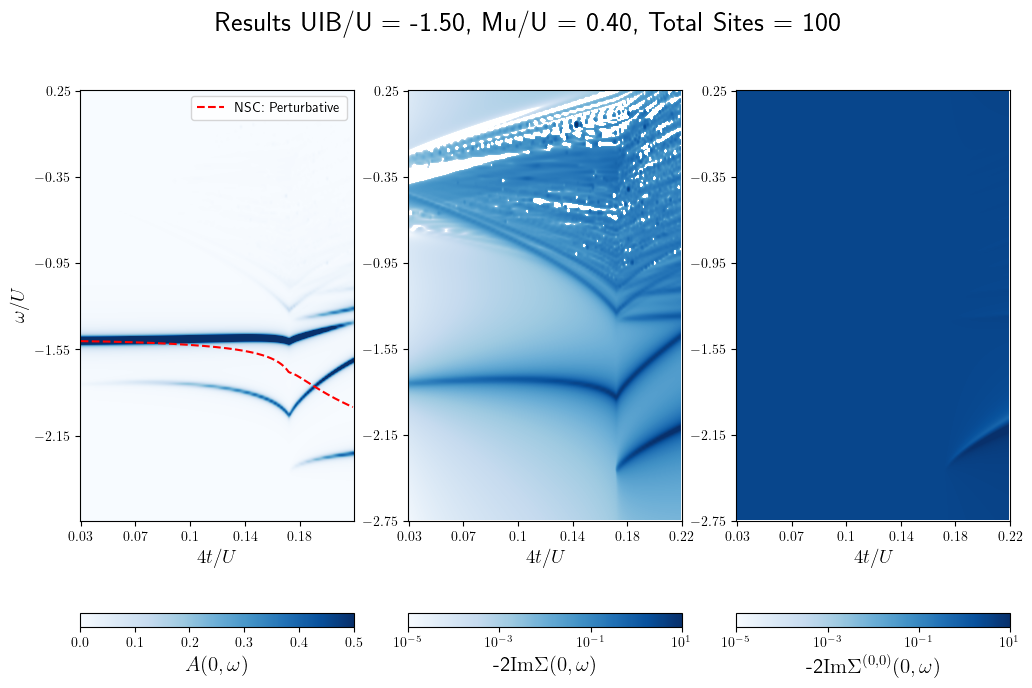

In [10]:
plt.rcParams['text.usetex'] = True


# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'Bicubic'
color_map = 'Blues'
im1 = ax1.imshow( np.abs(SpectralFuncs_rot), interpolation = interp, cmap = color_map, aspect = aspect_ratio)#, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2 * np.imag(Sigma_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(2 * np.abs(Sigma00_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio,norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 6

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(dJUs), max(dJUs), num_xticks), 2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=14)
ax3.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
cb2 = plt.colorbar(im2,orientation="horizontal")
cb2.set_label(label = "-2$\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
cb3 = plt.colorbar(im3,orientation="horizontal")
cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
im1.set_clim(0, 0.5)
im2.set_clim(1e-5, 1e1)
im3.set_clim(1e-5, 1e1)



X, Y = np.meshgrid(dJUs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(dJUs, (dJUs.min(), dJUs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
#plot_y_pole = SpectralFuncs_rot.shape[0] - 1 - np.interp(pol_w, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))


# Overlay the plot on top of the imshow figure
ax1.plot(plot_x, plot_y, linestyle='--', label='NSC:  Perturbative', color='red', linewidth=1.5)
#ax1.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
#ax2.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
ax1.legend()
#ax2.legend()
fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
plt.show()

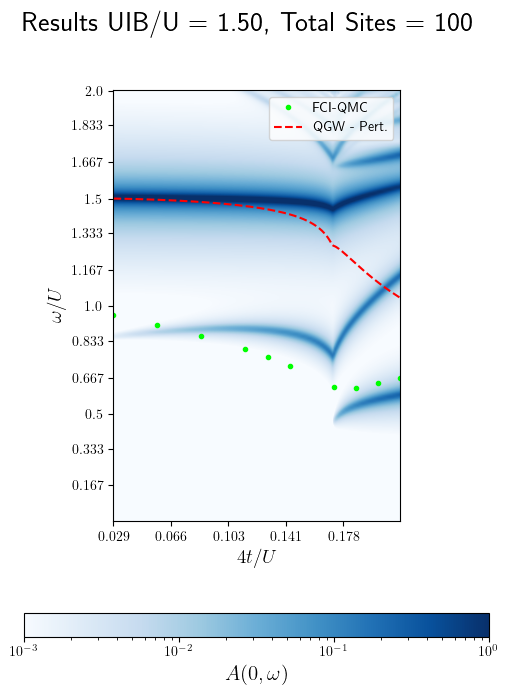

In [6]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, ax1 = plt.subplots(ncols = 1, figsize = (6,8)) # (6,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 1.5#'auto'#1
color_map = 'Blues'
interp = 'bicubic'
im1 = ax1.imshow(np.abs(SpectralFuncs_rot), interpolation = interp, cmap=color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 13

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(dJUs), max(dJUs), num_xticks),3)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 3)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)

ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)

ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
im1.set_clim(1e-3,1e0)
#im1.set_clim(0,0.25)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

# # # plot the extrapolated MC data.
Ep_M = Ep_Matija_UIB_1p5
dJUs_M = dJUs_Matija_QGW_UIB_m1p5
plot_x = np.interp(dJUs_M, (dJUs_M.min(), dJUs_M.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(Ep_M, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
ax1.plot(plot_x, plot_y, '.', label='FCI-QMC', color='lime')


#X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(dJUs, (dJUs.min(), dJUs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
#plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)
#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
#ax1.plot(plot_x, plot_0, linestyle = '-', color='white', linewidth=1.5)
#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

ax1.legend()

plt.show()

In [55]:
np.interp(dJUs_M, (dJUs_M.min(), dJUs_M.max()), (0, SpectralFuncs_rot.shape[1]-1))

array([  0. ,  99.5, 199. ])

In [51]:
dJUs_M

array([0.1292    , 0.17226667, 0.21533333])

In [7]:
## Save the figure 
filename = f'../figs/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/UIB_{UIB}_Mu_M_{grid.M}_N_{N}_num_en_{num_en}_num_dJU_{num_dJU}_dJU_max_{dJU_max}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [8]:
# Save the data

# Code to save results for different UIBs
#filename = f'./data/self_consistent_t/mean_field/t_scan/qmcorr_n_1p0/UIB_{UIB}_M_{grid.M}_N_{N}_num_en_{num_en}_num_dJU_{num_dJU}_dJU_max_{dJU_max}_eta_{eta}_cutoff_{cutoff}_full_crossover.hdf5'



with h5py.File(filename, 'w') as f:
    f.create_dataset('UIBs', data=dJUs)
    f.create_dataset('en_vector', data=en_vector)
    f.create_dataset('omega0s', data=omega0s)
    f.create_dataset('omega1s', data=omega1s)
    f.create_dataset('omega2s', data=omega2s)
    for i, dJU in enumerate(dJUs):
    # Create a group for this dJU value
        group = f.create_group(f'dJU_{dJU}')

        # Store the arrays in this group
        group.create_dataset('T11', data=T11[i, :])
        group.create_dataset('T12', data=T12[i, :])
        group.create_dataset('T21', data=T21[i, :])
        group.create_dataset('T22', data=T22[i, :])
        group.create_dataset('T22_SE', data=T22_F[i, :])
        group.create_dataset('SE_SI', data=SE_SI[i, :])
    

    # Create attributes for your parameters
    f.attrs['UIB'] = UIB
    f.attrs['muU'] = muU
    f.attrs['Lx'] = grid.Lx
    f.attrs['Ly'] = grid.Ly
    f.attrs['N'] = N


    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_SE = []
    SE_SI = []

    for count, dJU in enumerate(dJUs):
        group = f[f'dJU_{dJU}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_SE.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])